In [ ]:
import pandas as pd
from google.colab import files

uploaded = files.upload()
df = pd.read_csv('glassdoor_cleaned_text.csv')

Saving glassdoor_cleaned_text.csv to glassdoor_cleaned_text.csv


In [ ]:
from collections import Counter

# Join all cleaned reviews into one big string, then split into words
all_words = ' '.join(df['review_cons_cleaned'].dropna()).split()

# Count frequency of each word
word_counts = Counter(all_words)

print(word_counts.most_common(10))

[('work', 43), ('get', 20), ('hours', 13), ('long', 13), ('job', 13), ('dont', 12), ('management', 11), ('people', 11), ('physically', 10), ('time', 10)]


In [ ]:
stop_keywords = ['work', 'get', 'job', 'dont', 'people']
filtered_words = [word for word in all_words if word not in stop_keywords]
filtered_counts = Counter(filtered_words)

print(filtered_counts.most_common(10))

[('hours', 13), ('long', 13), ('management', 11), ('physically', 10), ('time', 10), ('much', 10), ('heavy', 10), ('environment', 9), ('like', 9), ('leadership', 9)]


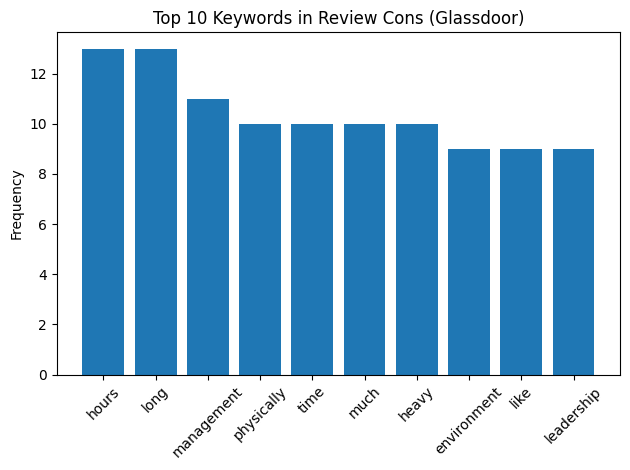

In [ ]:
import matplotlib.pyplot as plt

most_common = filtered_counts.most_common(10)
words, counts = zip(*most_common)

plt.bar(words, counts)
plt.title("Top 10 Keywords in Review Cons (Glassdoor)")
plt.xticks(rotation=45)
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

In [ ]:
from nltk.util import ngrams

bigrams = list(ngrams(filtered_words, 2))
trigrams = list(ngrams(filtered_words, 3))

bigram_counts = Counter(bigrams)
trigram_counts = Counter(trigrams)

print(bigram_counts.most_common(10))

[(('physically', 'demanding'), 5), (('break', 'time'), 4), (('long', 'hours'), 3), (('physical', 'mental'), 3), (('12', 'hours'), 3), (('long', 'shifts'), 3), (('use', 'break'), 3), (('physically', 'mentally'), 2), (('fast', 'paced'), 2), (('working', 'environment'), 2)]


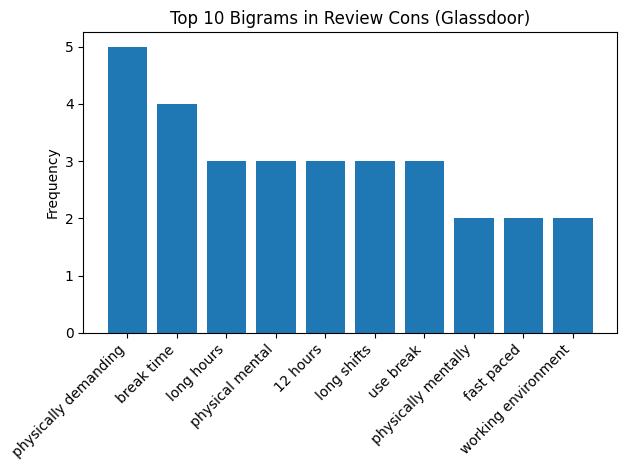

In [ ]:
common_bigrams = bigram_counts.most_common(10)
bg_labels = [' '.join(bg) for bg, count in common_bigrams]
bg_counts = [count for bg, count in common_bigrams]

plt.bar(bg_labels, bg_counts)
plt.title("Top 10 Bigrams in Review Cons (Glassdoor)")
plt.xticks(rotation=45, ha='right')
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

In [ ]:
trigrams = list(ngrams(filtered_words, 3))
trigram_counts = Counter(trigrams)
print(trigram_counts.most_common(10))

[(('use', 'break', 'time'), 3), (('fines', 'de', 'semana'), 2), (('mandatory', 'extra', 'time'), 2), (('moved', 'around', 'lot'), 2), (('10', 'hour', 'shifts'), 2), (('inhumane', 'draining', 'physically'), 1), (('draining', 'physically', 'mentally'), 1), (('physically', 'mentally', 'sticks'), 1), (('mentally', 'sticks', 'rules'), 1), (('sticks', 'rules', 'completing'), 1)]


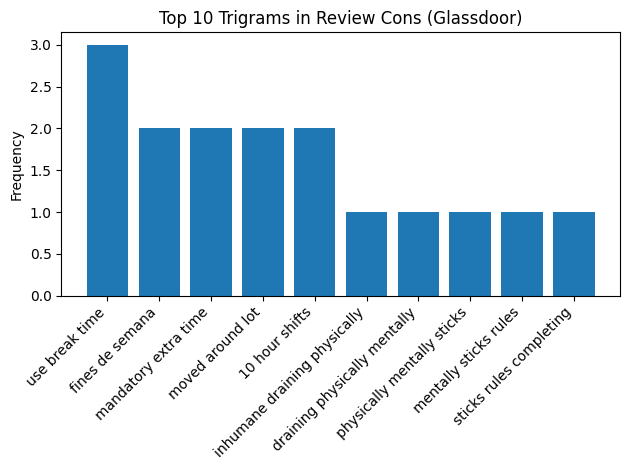

In [ ]:
common_trigrams = trigram_counts.most_common(10)
tg_labels = [' '.join(tg) for tg, count in common_trigrams]
tg_counts = [count for tg, count in common_trigrams]

plt.bar(tg_labels, tg_counts)
plt.title("Top 10 Trigrams in Review Cons (Glassdoor)")
plt.xticks(rotation=45, ha='right')
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

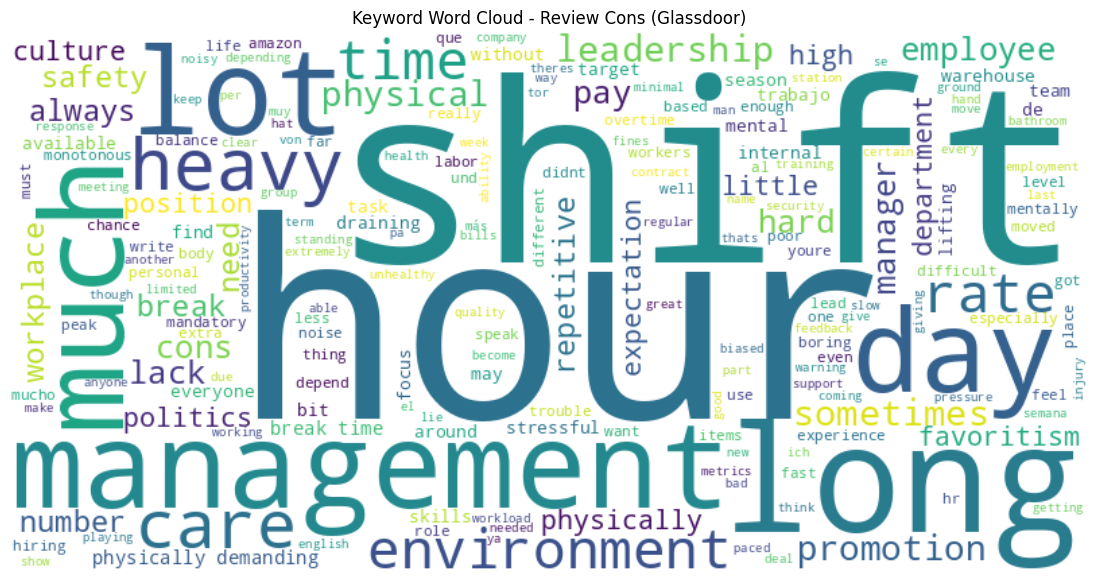

In [ ]:
!pip install wordcloud
from wordcloud import WordCloud

wordcloud = WordCloud(width=800, height=400, background_color='white').generate(' '.join(filtered_words))

plt.figure(figsize=(15, 7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Keyword Word Cloud - Review Cons (Glassdoor)")
plt.show()